# 01 - Análisis Exploratorio de Datos

## 1. Comprensión del Problema

La pérdida de clientes (**customer churn**) representa uno de los principales desafíos para las empresas, ya que la adquisición de nuevos clientes suele requerir mayores recursos que la retención de clientes existentes.

En este proyecto se busca desarrollar una solución basada en **Machine Learning** capaz de identificar clientes con alta probabilidad de abandonar un servicio de telecomunicaciones, permitiendo anticipar posibles bajas y apoyar la definición de estrategias de retención.

El análisis se complementará con una etapa de **segmentación de clientes mediante aprendizaje no supervisado**, con el objetivo de identificar grupos de clientes con características y comportamientos similares.

### 1.1 Objetivos del proyecto

Los principales objetivos son:

- Analizar las características de los clientes y su relación con el abandono del servicio.
- Desarrollar un modelo de clasificación binaria para predecir la probabilidad de churn.
- Identificar los factores más relevantes asociados a la pérdida de clientes mediante técnicas de interpretabilidad.
- Crear segmentos de clientes utilizando técnicas de clustering para descubrir diferentes perfiles dentro de la base de clientes.
- Desplegar una aplicación interactiva que permita realizar predicciones y explorar los segmentos identificados.

### 1.2 Definición del problema de Machine Learning

Este proyecto se plantea como un problema de **clasificación binaria supervisada**.

La variable objetivo será:

**Churn**

- `Yes`: el cliente abandonó el servicio.
- `No`: el cliente continúa utilizando el servicio.

El modelo aprenderá patrones a partir de las características históricas de los clientes para estimar la probabilidad de abandono de nuevos clientes. Adicionalmente, se desarrollará un análisis de **segmentación no supervisada** utilizando las características de los clientes, sin considerar la variable objetivo, con el propósito de identificar grupos con comportamientos similares.

### 1.3 Pregunta de negocio

> ¿Es posible identificar anticipadamente a los clientes con mayor riesgo de abandono y comprender los perfiles de clientes existentes para diseñar mejores estrategias de retención?

## 2. Descripción del Dataset

El dataset utilizado en este proyecto corresponde a información histórica de clientes de una empresa de telecomunicaciones, con el objetivo de analizar los factores asociados al abandono del servicio (**customer churn**).

Cada registro representa un cliente y contiene información relacionada con sus características demográficas, servicios contratados, tipo de contrato, información de facturación y comportamiento dentro de la relación comercial.

### 2.1 Información general

- **Número de registros:** 7,043 clientes.
- **Número de variables:** 21 columnas.
- **Variable objetivo:** `Churn`.
- **Tipo de problema principal:** Clasificación binaria.
- **Problema complementario:** Segmentación de clientes mediante clustering.

### 2.2 Descripción de las variables

El dataset contiene variables agrupadas en las siguientes categorías:

#### Información demográfica

Características generales del cliente:

- Género (`gender`).
- Edad del cliente (``SeniorCitizen	``).
- Estado de pareja (`Partner`).
- Dependientes (`Dependents`).

#### Información de cuenta

Variables relacionadas con la antigüedad y relación comercial:

- Antigüedad del cliente (`tenure`).
- Tipo de contrato (` Contract`).
- Facturación electrónica (`PaperlessBilling`).
- Método de pago (`PaymentMethod`).

#### Servicios contratados

Información sobre los servicios utilizados por cada cliente:

- Servicio telefónico (`PhoneService`).
- Múltiples líneas (`MultipleLines`).
- Servicio de internet (`InternetService`).
- Seguridad en línea (`OnlineSecurity`).
- Respaldo en línea (`OnlineBackup`).
- Protección del dispositivo (`DeviceProtection`).
- Soporte técnico (`TechSupport`).
- Servicios de streaming (`StreamingTV`, `StreamingMovies`).

#### Información financiera

Variables relacionadas con los pagos del cliente:

- Cargos mensuales (`MonthlyCharges`).
- Cargos totales acumulados (`TotalCharges`).

#### Variable objetivo

La variable objetivo del proyecto es:

**`Churn`**

Representa si el cliente abandonó el servicio:

- `Yes`: el cliente canceló el servicio.
- `No`: el cliente continúa siendo cliente.

### 2.3 Fuente del Dataset

El dataset corresponde al conjunto **Telco Customer Churn**, ampliamente utilizado para análisis de retención de clientes y desarrollo de modelos predictivos de clasificación.

## 3. Inspección Inicial

En esta sección se realiza una revisión inicial del dataset con el objetivo de comprender su tamaño, estructura y tipos de variables.

### 3.1 Importación de librerías y carga del dataset

In [34]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

# Load the autoreload extension to automatically reload modules when they change
# Set autoreload mode to 2: reload all modules before executing user code
%load_ext autoreload
%autoreload 2 

# import eda modules
from src.eda.visualizations import (
    plot_categorical_distributions,
    plot_categorical_churn_rates
)

# Load dataset
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")

df.head()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 3.2 Inspección inicial de los datos

In [2]:
# Dataset dimensions
print(f'Dataset dimensions: \nRows: {df.shape[0]}, Columns: {df.shape[1]}')

Dataset dimensions: 
Rows: 7043, Columns: 21


In [3]:
# General structure and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Count duplicated rows
print(f"Total duplicated rows: {df.duplicated().sum()}")

Total duplicated rows: 0


In [5]:
# Count missing values per column
print("========= Missing values in each column =========")
with pd.option_context('display.max_rows', None):
    print(df.isnull().sum().sort_values(ascending=False))

========= Missing values in each column =========
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## 4. Análisis Exploratorio de Datos

El análisis exploratorio de datos tendrá como objetivo comprender las características principales de los clientes y analizar la relación entre las variables disponibles y el abandono del servicio (**Churn**).

Durante esta etapa se explorarán la variable objetivo y los diferentes grupos de variables del dataset, identificando patrones, diferencias entre clientes que abandonaron y aquellos que permanecieron activos, así como posibles factores asociados con una mayor probabilidad de cancelación.

El análisis se enfocará principalmente en responder preguntas como:

- ¿Cuál es la proporción de clientes que abandonan el servicio?
- ¿Qué características demográficas presentan mayor relación con el churn?
- ¿Cómo influyen el tipo de contrato, los servicios contratados y la antigüedad del cliente en la retención?
- ¿Existe alguna relación entre los cargos del cliente y la probabilidad de abandono?

Los hallazgos obtenidos durante esta etapa servirán como base para la selección de variables candidatas al modelo y la creación de características derivadas (**feature engineering**) en las siguientes fases del proyecto.

### 4.1 Análisis de la variable objetivo (`Churn`)

La variable objetivo del proyecto es `Churn`, que indica si un cliente abandonó el servicio de la compañía. Antes de analizar la relación entre las características de los clientes y el abandono, es necesario comprender la distribución de esta variable y determinar si existe un desbalance entre sus categorías.

Este análisis permitirá establecer una referencia inicial sobre la proporción de clientes que abandonan el servicio y aquellos que permanecen, además de identificar posibles consideraciones que deberán tenerse en cuenta durante la etapa de modelado.

El análisis de esta sección se centrará en:

- Examinar la distribución de las categorías de `Churn`.
- Calcular la cantidad y proporción de clientes que abandonaron y permanecieron.
- Evaluar el nivel de desbalance de la variable objetivo.
- Identificar las implicaciones de esta distribución para la selección de métricas de evaluación del modelo.

Una vez comprendida la distribución de la variable objetivo, se analizará cómo las diferentes características de los clientes se relacionan con el abandono del servicio.

#### Distribución de la variable objetivo

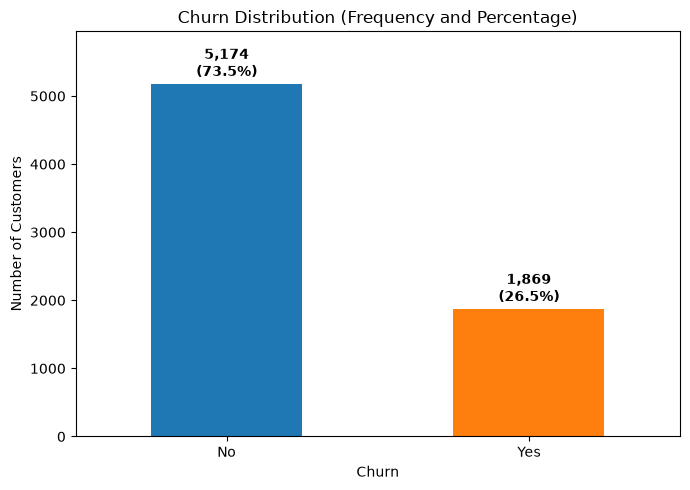

In [11]:
# Calculate counts and percentages ensuring matching indices
churn_counts = df["Churn"].value_counts()
churn_percentages = df["Churn"].value_counts(normalize=True).mul(100)

# Initialize a single plot figure
fig, ax = plt.subplots(figsize=(7, 5))

# Plot absolute frequencies
churn_counts.plot(kind="bar", ax=ax, color=["#1f77b4", "#ff7f0e"])
ax.set_title("Churn Distribution (Frequency and Percentage)")
ax.set_xlabel("Churn")
ax.set_ylabel("Number of Customers")
ax.tick_params(axis="x", rotation=0)

# Annotate bars with both absolute count and percentage values
for i, label in enumerate(churn_counts.index):
    count = churn_counts[label]
    pct = churn_percentages[label]
    
    ax.text(
        i, 
        count + (churn_counts.max() * 0.01), 
        f"{count:,}\n({pct:.1f}%)", 
        ha="center", 
        va="bottom", 
        fontsize=10, 
        fontweight="bold"
    )

# Adjust y-axis limit to prevent label clipping
ax.set_ylim(0, churn_counts.max() * 1.15)

plt.tight_layout()
plt.show()


De los **7,043 clientes** presentes en el dataset, **5,174 (73.5%)** permanecen con la compañía (`No`), mientras que **1,869 (26.5%)** han abandonado el servicio (`Yes`).

Por lo tanto, aproximadamente **1 de cada 4 clientes** corresponde a un caso de churn.

La distribución muestra un desbalance moderado entre las clases. Aunque la categoría `No` representa la mayoría de los registros, la clase `Yes` cuenta con un número considerable de observaciones para desarrollar un modelo de clasificación.

#### Implicaciones para el Modelado

El desbalance observado debe ser considerado durante la evaluación de los modelos. En este escenario, un modelo podría alcanzar un nivel elevado de `Accuracy` simplemente al predecir mayoritariamente la clase `No`, sin necesariamente tener una buena capacidad para identificar a los clientes que abandonan.

Por esta razón, durante la etapa de modelado no se utilizará `Accuracy` como única métrica de evaluación. Se prestará especial atención a métricas como **Precision, Recall, F1-Score y ROC-AUC**, considerando especialmente el desempeño sobre la clase minoritaria `Yes`.

La distribución de la variable objetivo proporciona así un punto de partida para comprender el problema de clasificación. Sin embargo, conocer únicamente cuántos clientes abandonan no permite explicar qué características están asociadas con el churn.

Por ello, en las siguientes secciones se analizarán los diferentes grupos de variables disponibles en el dataset, comparando el comportamiento de los clientes que permanecieron con aquellos que abandonaron el servicio. El objetivo será identificar patrones y relaciones que puedan aportar información relevante para las etapas posteriores de **Feature Engineering y modelado**.

### 4.2 Análisis de Variables Demográficas

En esta sección se analizará la relación entre las características demográficas de los clientes y el abandono del servicio (`Churn`).

El objetivo es determinar si existen diferencias en las tasas de abandono entre distintos perfiles demográficos y si estas variables podrían aportar información relevante para la predicción del churn.

Las variables que se analizarán son:

- `gender`: género del cliente.
- `SeniorCitizen`: indica si el cliente pertenece al grupo de adultos mayores.
- `Partner`: indica si el cliente tiene pareja.
- `Dependents`: indica si el cliente tiene dependientes.

Para las variables categóricas se analizará principalmente la **tasa de churn de cada categoría**, ya que esta métrica permite comparar directamente la proporción de clientes que abandonaron el servicio dentro de cada grupo. Además de observar las diferencias en las tasas de abandono, se considerará el tamaño de cada grupo para evitar interpretar diferencias basadas en categorías con un número reducido de observaciones.

Los resultados de este análisis permitirán identificar posibles **patrones de asociación** entre las características demográficas y el churn, así como determinar qué variables podrían ser relevantes para nuestro problema.

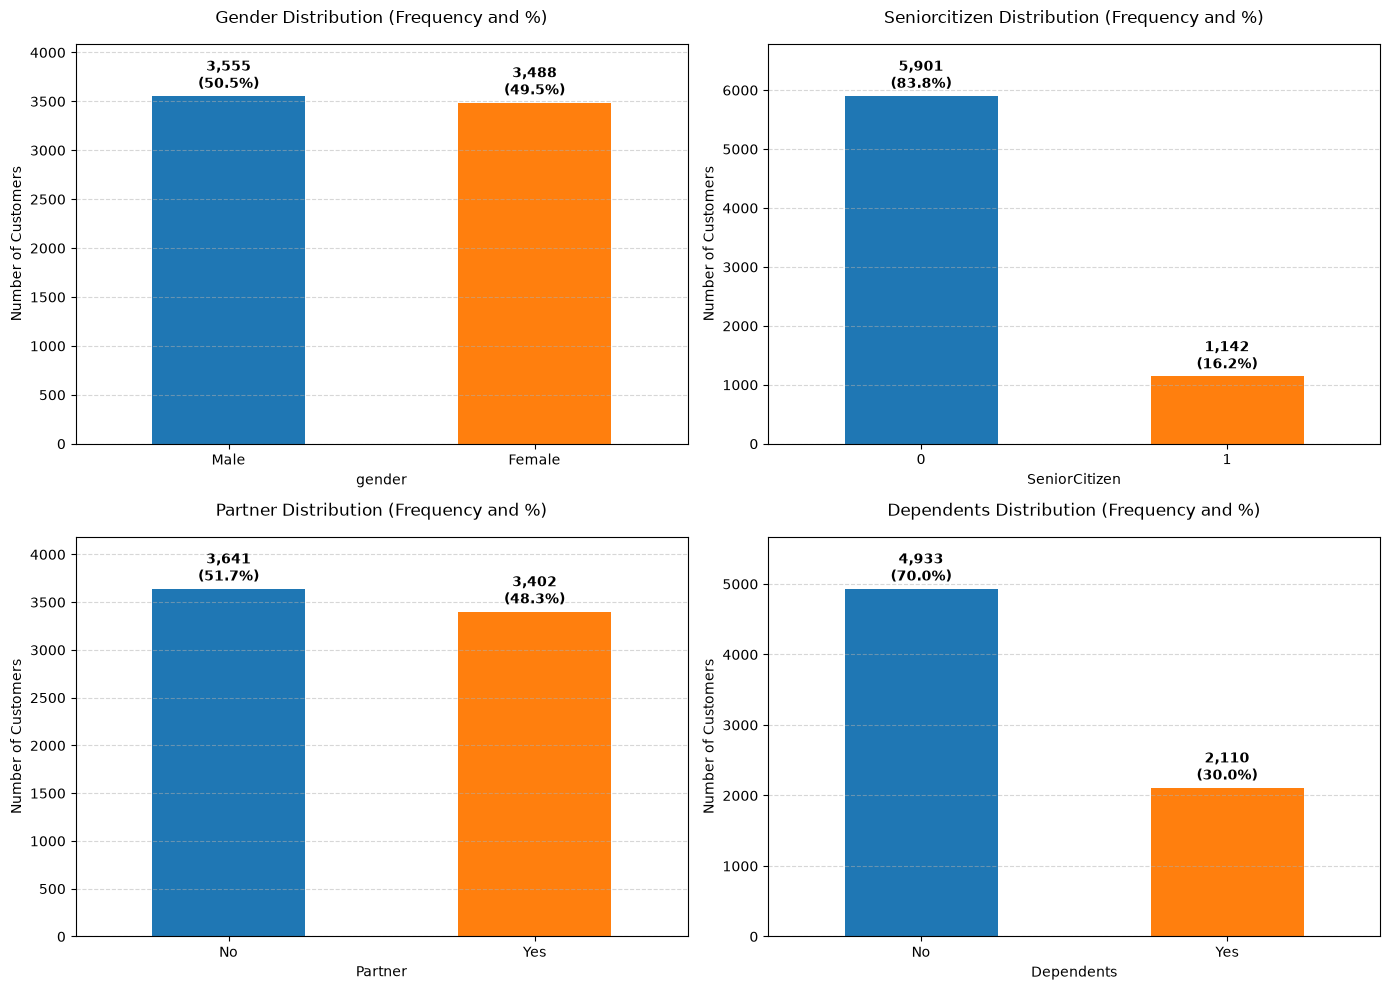

In [12]:
# Define the list of customer demographic features to analyze
demographic_features = ["gender", "SeniorCitizen", "Partner", "Dependents"]

# Plot distributions for the demographic features
plot_categorical_distributions(df, demographic_features)

In [8]:
# Iterate through each defined demographic variable
for var in demographic_features:
    # Calculate absolute frequencies for each category
    counts = df[var].value_counts()
    # Calculate relative frequencies as percentages
    percentages = df[var].value_counts(normalize=True).mul(100)

    # Combine both metrics into a single structured DataFrame
    summary = pd.concat([counts, percentages], axis=1, keys=["Count", "Percentage (%)"])
    
    # Print the variable name as a header
    print(f"--- {var} ---")
    # Print the formatted frequency table
    print(summary)
    # Print a blank line for visual separation
    print("")


--- gender ---
        Count  Percentage (%)
gender                       
Male     3555        50.47565
Female   3488        49.52435

--- SeniorCitizen ---
               Count  Percentage (%)
SeniorCitizen                       
0               5901       83.785319
1               1142       16.214681

--- Partner ---
         Count  Percentage (%)
Partner                       
No        3641        51.69672
Yes       3402        48.30328

--- Dependents ---
            Count  Percentage (%)
Dependents                       
No           4933       70.041176
Yes          2110       29.958824



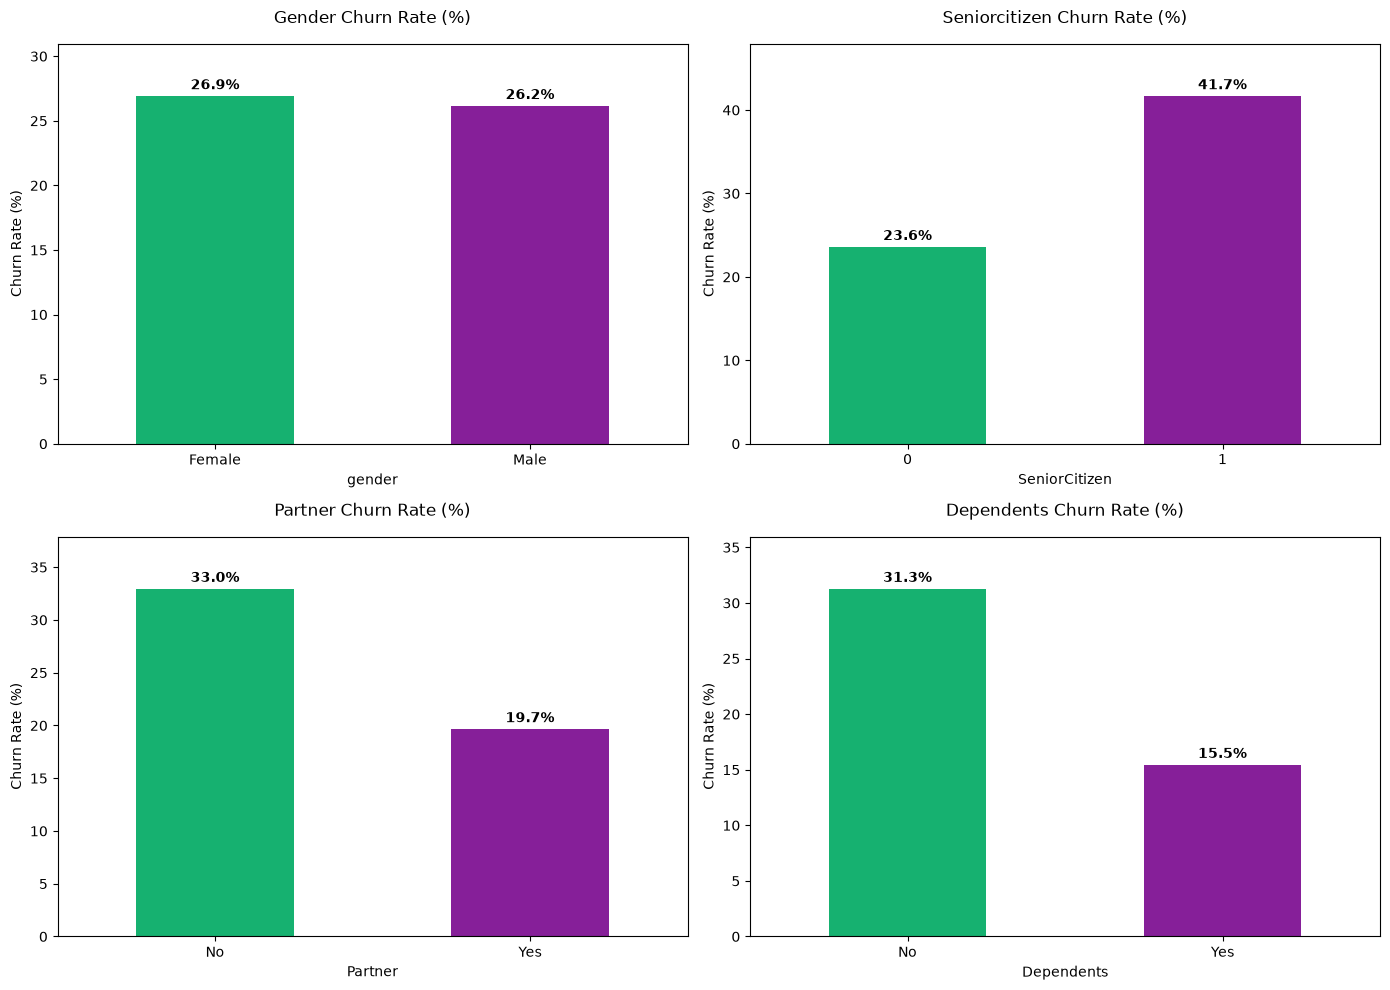

In [35]:
# Create a boolean target column where 'Yes' becomes True and 'No' becomes False
df["Churn_bool"] = df["Churn"].astype(str).str.lower() == "yes"

plot_categorical_churn_rates(df, demographic_features, 'Churn_bool')

In [33]:
# Iterate through each defined demographic variable
for var in demographic_features:
    # Calculate the mean churn rate per category and convert to percentage
    churn_rates = df.groupby(var)["Churn_bool"].mean().mul(100)

    # Convert the Series to a structured DataFrame for cleaner display
    summary = churn_rates.to_frame(name="Churn Rate (%)")

    # Print the variable header and its corresponding rates table
    print(f"--- Churn Rate by {var} ---")
    print(summary.round(1))  # Round to 1 decimal place for readability
    print("")


--- Churn Rate by gender ---
        Churn Rate (%)
gender                
Female            26.9
Male              26.2

--- Churn Rate by SeniorCitizen ---
               Churn Rate (%)
SeniorCitizen                
0                        23.6
1                        41.7

--- Churn Rate by Partner ---
         Churn Rate (%)
Partner                
No                 33.0
Yes                19.7

--- Churn Rate by Dependents ---
            Churn Rate (%)
Dependents                
No                    31.3
Yes                   15.5

